#### ML Fundamentals Day_49
- Unsupervised ML
   - K-Means Clustering

In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
## Gnerating Random Datasets
X,y = make_blobs(
     n_samples=20000,
     n_features=2,
     centers=4,
     random_state=42
)

In [3]:
X

array([[-5.04580246, -6.3806088 ],
       [-2.12784479, 10.37981259],
       [ 3.2987488 ,  3.50115126],
       ...,
       [ 4.67383572,  1.61173549],
       [-3.176531  ,  6.77237019],
       [-8.62060545, -7.49673323]], shape=(20000, 2))

In [4]:
y # ignoring output

array([2, 0, 1, ..., 1, 0, 2], shape=(20000,))

<Axes: >

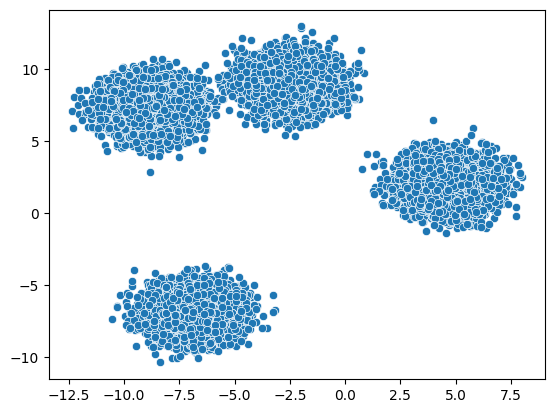

In [5]:
## Visualize Plot
sns.scatterplot(x=X[:,0],y=X[:,1])

In [6]:
## K-Means Clustering
from sklearn.cluster import KMeans
K = 3
kmeans = KMeans(
     n_clusters=K,
     random_state=42
)
labels = kmeans.fit_predict(X)
labels # cluster number

array([2, 1, 0, ..., 0, 1, 2], shape=(20000,), dtype=int32)

<Axes: >

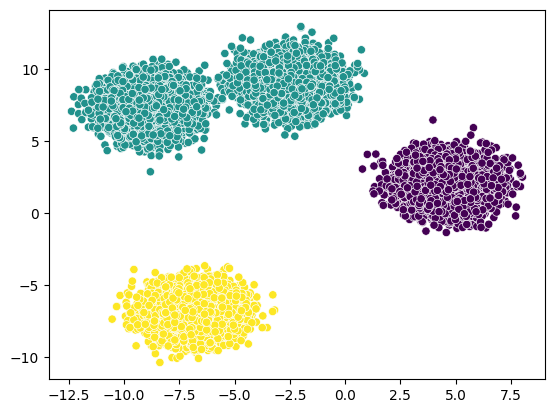

In [7]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

- How to choose k values
   - Elbow Method
   - Silhouette Score

In [8]:
## Elbow Method
wcss = []
for k in range(1,21):
     kmeans = KMeans(n_clusters=k)
     kmeans.fit_predict(X)
     wcss.append(kmeans.inertia_)

<Axes: >

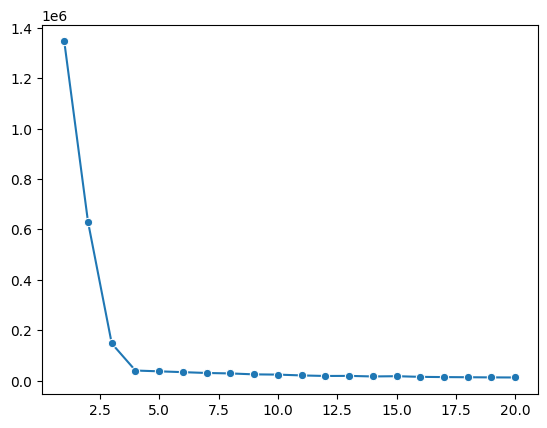

In [9]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [10]:
!pip install kneed

In [ ]:
## Kneed Module (automatically to find of K for clusters)
from kneed import KneeLocator
knee = KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
print(f"Optimal K={knee.elbow}")

Optimal K=4


In [12]:
## Silhouette Score
from sklearn.metrics import silhouette_score
ss = []
for k in range(2,21):
     kmeans = KMeans(n_clusters=k)
     labels = kmeans.fit_predict(X)
     score = silhouette_score(X,labels)
     ss.append(score)

<Axes: >

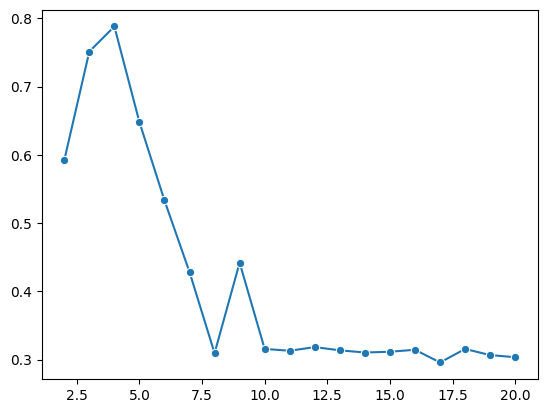

In [13]:
## Plot K & ss
sns.lineplot(x=range(2,21),y=ss,marker='o')